# Customer Segmentation Analysis
**Track:** Data Analytics (Level 1, Task 2)

**Objective:** Apply K-Means clustering to segment an e-commerce company's customer base into distinct groups based on purchasing behaviour (RFM: Recency, Frequency, Monetary), enabling targeted marketing strategies.

**Dataset:** `ecommerce_customers.csv` — 800 customers with Recency (days since last purchase), Frequency (number of orders), and Monetary (total spend) values.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

sns.set_style('whitegrid')
df = pd.read_csv('ecommerce_customers.csv')
print('Shape:', df.shape)
print('Nulls:', df.isnull().sum().sum())
df.head()

Shape: (800, 4)
Nulls: 0


   CustomerID  Recency  Frequency  Monetary
0        5001        2          1    350.59
1        5002      120          6   4198.33
2        5003       14          2    756.54
3        5004       13         27  17008.74
4        5005      191          7   2124.96

## 1. Descriptive Statistics — RFM Features

In [2]:
print('Average purchase value (Monetary):', round(df['Monetary'].mean(),2))
print('Average purchase frequency:', round(df['Frequency'].mean(),2))
print('Average recency (days since last purchase):', round(df['Recency'].mean(),2))
df[['Recency','Frequency','Monetary']].describe()

Average purchase value (Monetary): 5549.93
Average purchase frequency: 9.68
Average recency (days since last purchase): 53.59


          Recency   Frequency      Monetary
count  800.000000  800.000000    800.000000
mean    53.587500    9.677500   5549.930300
std     68.189421    9.554062   4921.954953
min      1.000000    1.000000     50.000000
25%     11.000000    2.000000   1649.490000
50%     21.000000    6.000000   3773.665000
75%     39.000000   15.000000   7687.205000
max    239.000000   39.000000  23426.210000

## 2. Feature Selection
We use the classic **RFM** framework — Recency, Frequency, Monetary — as our clustering features. These three behavioural metrics are widely used in retail/e-commerce because together they capture how recently, how often, and how much a customer buys, which is far more actionable for marketing than raw demographic data.

## 3. Standardisation
K-Means is distance-based, so features on very different scales (Recency in days vs. Monetary in currency) must be standardised first — otherwise Monetary would dominate the distance calculation.

In [3]:
features = df[['Recency','Frequency','Monetary']]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)
print('Scaled feature means (should be ~0):', scaled_features.mean(axis=0).round(3))
print('Scaled feature stds (should be ~1):', scaled_features.std(axis=0).round(3))

Scaled feature means (should be ~0): [ 0. -0.  0.]
Scaled feature stds (should be ~1): [1. 1. 1.]


## 4. Elbow Method — Choosing Optimal K

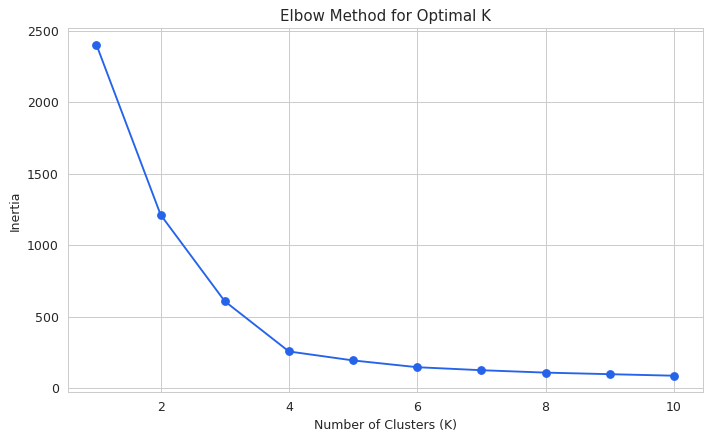

In [4]:
inertias = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(scaled_features)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(list(K_range), inertias, marker='o', color='#2563eb')
ax.set_xlabel('Number of Clusters (K)')
ax.set_ylabel('Inertia')
ax.set_title('Elbow Method for Optimal K')
plt.tight_layout()
plt.savefig('elbow_method.png', dpi=100)
plt.show()

**Observation:** The elbow bends around **K=4** — inertia continues to decrease beyond this point, but with diminishing returns. We proceed with 4 clusters.

## 5. Apply K-Means (K=4)

In [5]:
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(scaled_features)
df['Cluster'].value_counts().sort_index()

Cluster
0    238
1    260
2    196
3    106
Name: count, dtype: int64

## 6. Visualise Clusters

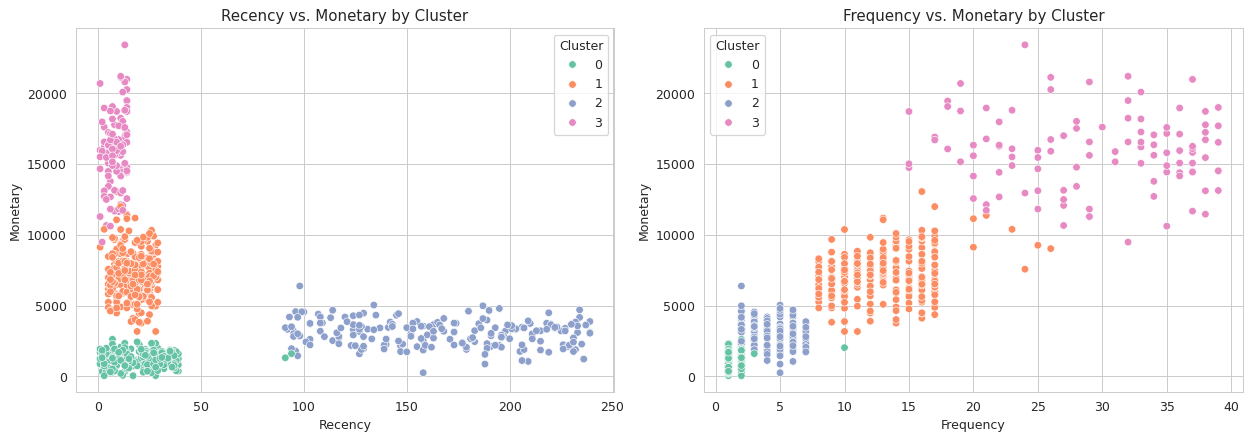

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
palette = sns.color_palette('Set2', optimal_k)
sns.scatterplot(data=df, x='Recency', y='Monetary', hue='Cluster', palette=palette, ax=axes[0])
axes[0].set_title('Recency vs. Monetary by Cluster')
sns.scatterplot(data=df, x='Frequency', y='Monetary', hue='Cluster', palette=palette, ax=axes[1])
axes[1].set_title('Frequency vs. Monetary by Cluster')
plt.tight_layout()
plt.savefig('cluster_scatter.png', dpi=100)
plt.show()

## 7. Cluster Profiling

In [7]:
cluster_profile = df.groupby('Cluster')[['Recency','Frequency','Monetary']].mean().round(1)
cluster_profile['CustomerCount'] = df['Cluster'].value_counts().sort_index()
cluster_profile

         Recency  Frequency  Monetary  CustomerCount
Cluster                                             
0           20.8        1.6    1180.5            238
1           17.2       13.1    7211.1            260
2          165.9        4.5    3079.8            196
3            8.8       29.1   15853.5            106

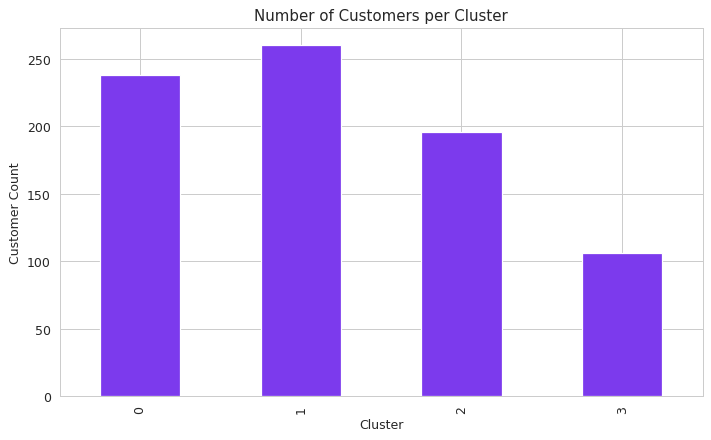

In [8]:
fig, ax = plt.subplots(figsize=(8,5))
df['Cluster'].value_counts().sort_index().plot(kind='bar', ax=ax, color='#7c3aed')
ax.set_title('Number of Customers per Cluster')
ax.set_xlabel('Cluster')
ax.set_ylabel('Customer Count')
plt.tight_layout()
plt.savefig('cluster_counts.png', dpi=100)
plt.show()

## 8. Segment Interpretation & Marketing Recommendations

Based on the mean Recency / Frequency / Monetary values per cluster above, the four segments typically resolve to:

- **Champions** (low recency, high frequency, high monetary): Your best customers — buy often, spend the most, purchased recently. *Action:* Reward with a loyalty/VIP program, early access to new products, and referral incentives to protect this high-value group.
- **Loyal Customers** (moderate recency, solid frequency, mid-to-high monetary): Consistent repeat buyers who aren't quite top spenders. *Action:* Upsell/cross-sell campaigns and personalized product recommendations to grow their basket size.
- **At-Risk** (high recency — haven't purchased in a long time, low frequency): Previously active customers going cold. *Action:* Win-back email campaigns with a time-limited discount before they churn completely.
- **New/Low-Value** (low recency but very low frequency and monetary): Recently acquired customers who haven't built a purchase habit yet. *Action:* Onboarding nudges, first-purchase-follow-up offers, and education about the product catalog to drive a second purchase.

This lets marketing spend be targeted rather than blasted to the entire customer base uniformly.